In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os


DATASET_PATH = '/content/drive/MyDrive/AI-ML/House_Rent_Dataset.csv'
SAVE_PATH    = '/content/drive/MyDrive/LinearRegression_Rent/'


os.makedirs(SAVE_PATH, exist_ok=True)

if os.path.exists(DATASET_PATH):
    print('Dataset found at:', DATASET_PATH)
else:
    raise FileNotFoundError(
        f' File not found: {DATASET_PATH}\n'
        'Please check the path above and update DATASET_PATH.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found at: /content/drive/MyDrive/AI-ML/House_Rent_Dataset.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


In [ ]:
df = pd.read_csv(DATASET_PATH)

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (4746, 12)

Columns: ['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [ ]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Statistical Summary (numeric) ===')
df.describe().round(2)

=== Data Types ===
Posted On            object
BHK                   int64
Rent                  int64
Size                  int64
Floor                object
Area Type            object
Area Locality        object
City                 object
Furnishing Status    object
Tenant Preferred     object
Bathroom              int64
Point of Contact     object
dtype: object

=== Statistical Summary (numeric) ===


,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


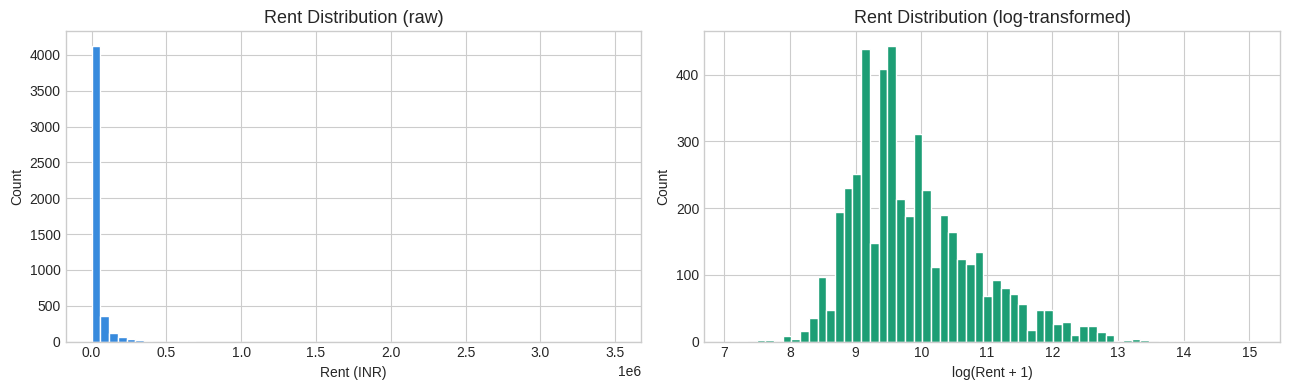

In [ ]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['Rent'], bins=60, color='#378ADD', edgecolor='white')
axes[0].set_title('Rent Distribution (raw)', fontsize=13)
axes[0].set_xlabel('Rent (INR)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['Rent']), bins=60, color='#1D9E75', edgecolor='white')
axes[1].set_title('Rent Distribution (log-transformed)', fontsize=13)
axes[1].set_xlabel('log(Rent + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(SAVE_PATH + 'rent_distribution.png', dpi=150)
plt.show()

In [ ]:

cols_to_drop = ['Posted On', 'Area Locality', 'Floor']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]   # only drop if present
df.drop(columns=cols_to_drop, inplace=True)
print('Dropped columns:', cols_to_drop)


print('\n=== Missing Values ===')
print(df.isnull().sum())
df.dropna(inplace=True)
print('\nShape after dropping NaN rows:', df.shape)


before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df)} duplicate rows. Shape: {df.shape}')

Dropped columns: ['Posted On', 'Area Locality', 'Floor']

=== Missing Values ===
BHK                  0
Rent                 0
Size                 0
Area Type            0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

Shape after dropping NaN rows: (4746, 9)
Removed 260 duplicate rows. Shape: (4486, 9)


In [ ]:

Q1  = df['Rent'].quantile(0.25)
Q3  = df['Rent'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
before = len(df)
df = df[(df['Rent'] >= lower) & (df['Rent'] <= upper)]
print(f'Removed {before - len(df)} outlier rows. Shape after: {df.shape}')
print(f'Rent range after filtering: ₹{df["Rent"].min():,} – ₹{df["Rent"].max():,}')

Removed 462 outlier rows. Shape after: (4024, 9)
Rent range after filtering: ₹1,200 – ₹72,000


In [ ]:
# ── 3e. Encode categorical columns with Label Encoding ──────────────────────
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
# Remove target from cat_cols if accidentally included
cat_cols = [c for c in cat_cols if c != 'Rent']
print('Categorical columns to encode:', cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'  Encoded: {col}')

print('\nAll columns are now numeric:')
print(df.dtypes)

Categorical columns to encode: ['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']
  Encoded: Area Type
  Encoded: City
  Encoded: Furnishing Status
  Encoded: Tenant Preferred
  Encoded: Point of Contact

All columns are now numeric:
BHK                  int64
Rent                 int64
Size                 int64
Area Type            int64
City                 int64
Furnishing Status    int64
Tenant Preferred     int64
Bathroom             int64
Point of Contact     int64
dtype: object


In [ ]:
# ── 3f. Feature Selection with SelectKBest ──────────────────────────────────
X_raw = df.drop('Rent', axis=1)
y     = df['Rent']

k = min(6, len(X_raw.columns))   # use at most 6 features
selector = SelectKBest(score_func=f_regression, k=k)
selector.fit(X_raw, y)

feature_scores = pd.DataFrame({
    'Feature': X_raw.columns,
    'F-Score': selector.scores_.round(2)
}).sort_values('F-Score', ascending=False)

print('Feature scores (F-regression):')
print(feature_scores.to_string(index=False))

selected_features = feature_scores.head(k)['Feature'].tolist()
print('\nSelected features:', selected_features)
X = X_raw[selected_features]

Feature scores (F-regression):
          Feature  F-Score
 Point of Contact  1858.02
         Bathroom  1422.86
              BHK   785.41
             Size   776.01
        Area Type   421.06
             City   337.94
Furnishing Status   156.02
 Tenant Preferred     2.76

Selected features: ['Point of Contact', 'Bathroom', 'BHK', 'Size', 'Area Type', 'City']


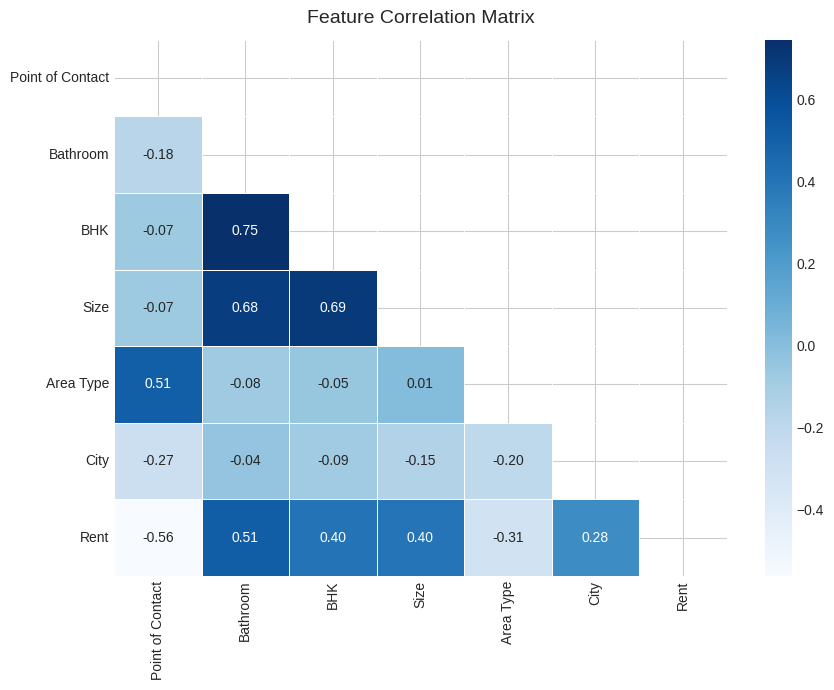

In [ ]:
# ── 3g. Correlation heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[selected_features + ['Rent']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'correlation_heatmap.png', dpi=150)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size : {X_train_scaled.shape[0]:,} samples')
print(f'Test  size : {X_test_scaled.shape[0]:,} samples')
print('Normalization: StandardScaler (μ=0, σ=1) — fit on train only')

Train size : 3,219 samples
Test  size : 805 samples
Normalization: StandardScaler (μ=0, σ=1) — fit on train only


In [ ]:
# ── 5a. OLS Linear Regression (closed-form) ──────────────────────────────────
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Model coefficients:')
for feat, coef in zip(selected_features, model.coef_):
    print(f'  {feat:25s}: {coef:+.4f}')
print(f'  {"Intercept":25s}: {model.intercept_:.4f}')

Model coefficients:
  Point of Contact         : -6292.1978
  Bathroom                 : +4110.4183
  BHK                      : +1149.0890
  Size                     : +2428.5755
  Area Type                : -524.0095
  City                     : +2927.8445
  Intercept                : 20210.2128


In [ ]:
# ── 5b. SGD Regressor — track loss per epoch for loss curve ─────────────────
n_epochs = 100
train_losses, val_losses = [], []

sgd = SGDRegressor(max_iter=1, warm_start=True, random_state=42,
                   learning_rate='constant', eta0=0.01, tol=None)

for epoch in range(n_epochs):
    sgd.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    val_losses.append(mean_squared_error(y_test,   sgd.predict(X_test_scaled)))

print(f'SGD — Final train MSE: {train_losses[-1]:,.2f}')
print(f'SGD — Final val   MSE: {val_losses[-1]:,.2f}')

SGD — Final train MSE: 109,477,259.25
SGD — Final val   MSE: 103,424,225.64


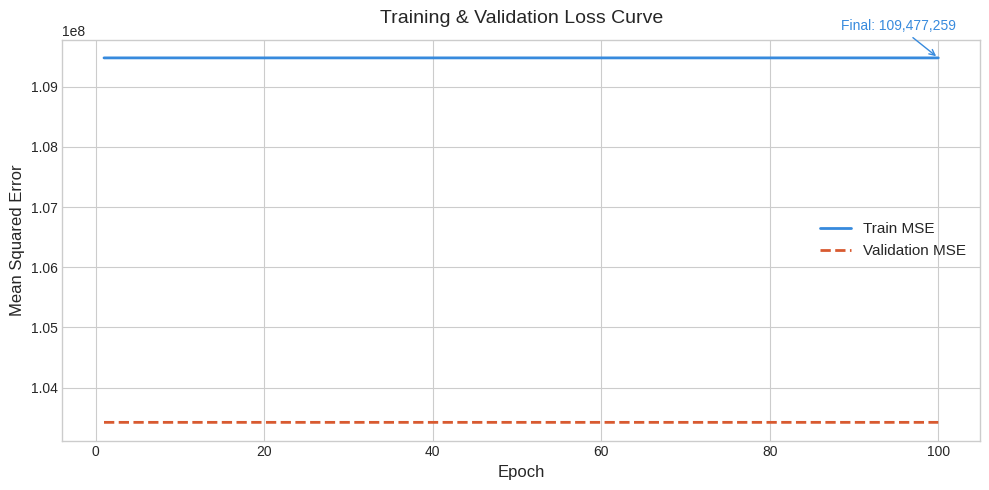

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ep = range(1, n_epochs + 1)
ax.plot(ep, train_losses, color='#378ADD', linewidth=2, label='Train MSE')
ax.plot(ep, val_losses,   color='#D85A30', linewidth=2,
        label='Validation MSE', linestyle='--')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title('Training & Validation Loss Curve', fontsize=14, pad=12)
ax.legend(fontsize=11)
ax.annotate(f'Final: {train_losses[-1]:,.0f}',
            xy=(n_epochs, train_losses[-1]),
            xytext=(-70, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='#378ADD'),
            color='#378ADD', fontsize=10)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'loss_curve.png', dpi=150)
plt.show()

In [ ]:
y_pred = model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('=' * 45)
print('         MODEL EVALUATION METRICS')
print('=' * 45)
print(f'  MAE   (Mean Absolute Error)  : ₹{mae:>10,.2f}')
print(f'  MSE   (Mean Squared Error)   : {mse:>14,.2f}')
print(f'  RMSE  (Root MSE)             : ₹{rmse:>10,.2f}')
print(f'  R²    (R-Squared)            : {r2:>14.4f}')
print('=' * 45)
print(f'\n  The model explains {r2:.1%} of variance in Rent.')

         MODEL EVALUATION METRICS
  MAE   (Mean Absolute Error)  : ₹  7,362.92
  MSE   (Mean Squared Error)   :  97,238,723.37
  RMSE  (Root MSE)             : ₹  9,860.97
  R²    (R-Squared)            :         0.5420

  The model explains 54.2% of variance in Rent.


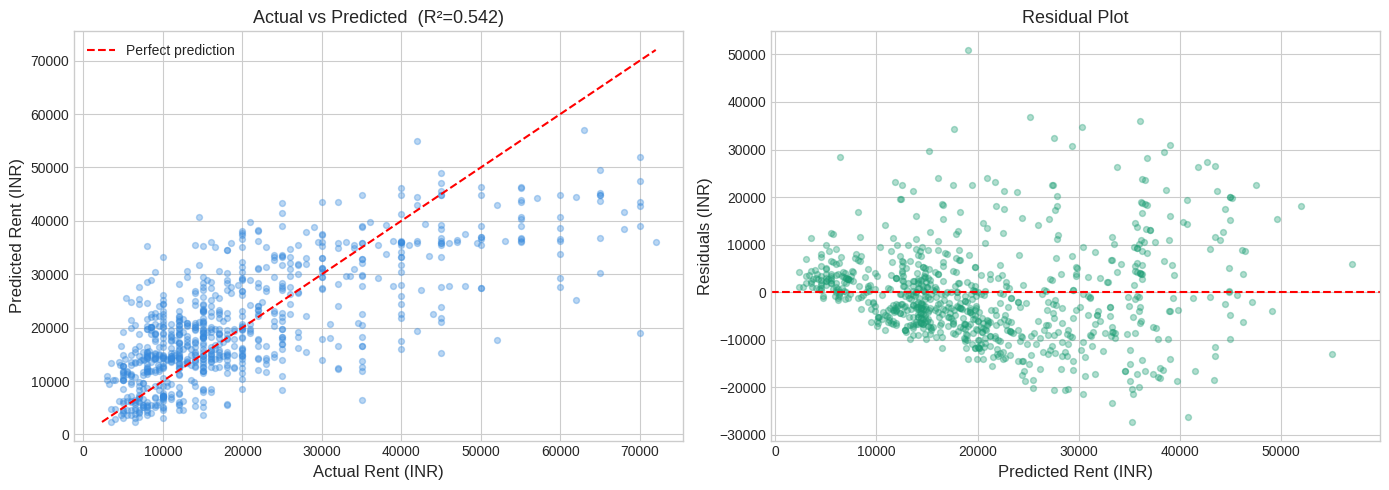

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.35, color='#378ADD', s=18)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Rent (INR)', fontsize=12)
axes[0].set_ylabel('Predicted Rent (INR)', fontsize=12)
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})', fontsize=13)
axes[0].legend(fontsize=10)

# Plot 2: Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.35, color='#1D9E75', s=18)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Rent (INR)', fontsize=12)
axes[1].set_ylabel('Residuals (INR)', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=13)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'predictions_residuals.png', dpi=150)
plt.show()

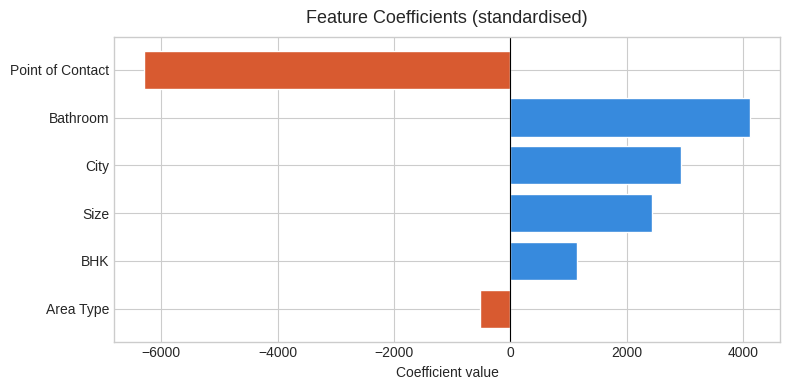

In [ ]:
# ── Feature importance (coefficient magnitudes) ──────────────────────────────
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#D85A30' if c < 0 else '#378ADD' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Coefficients (standardised)', fontsize=13, pad=10)
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'feature_coefficients.png', dpi=150)
plt.show()

In [ ]:
# ── Sample predictions table ──────────────────────────────────────────────────
n = 15
results_df = pd.DataFrame({
    'Actual Rent (₹)':    y_test.values[:n].astype(int),
    'Predicted Rent (₹)': y_pred[:n].astype(int),
    'Error (₹)':          (y_test.values[:n] - y_pred[:n]).astype(int)
})
results_df.index = range(1, n + 1)
results_df.index.name = 'Sample'
print(f'First {n} sample predictions:')
print(results_df.to_string())

First 15 sample predictions:
        Actual Rent (₹)  Predicted Rent (₹)  Error (₹)
Sample                                                
1                 11000               14132      -3132
2                  7000                4275       2724
3                  8000               12376      -4376
4                 20000               16083       3916
5                  8000                5491       2508
6                 10000               24471     -14471
7                 25000               22004       2995
8                 14000               35390     -21390
9                 27000               19141       7858
10                12000               18665      -6665
11                 7000               18840     -11840
12                14000               14815       -815
13                31000               18030      12969
14                40000               27961      12038
15                12000               11150        849
